# 05 — Segmentierung & Business-Simulation

**Scope:** Risiko-Segmentierung, Szenario-Simulation (3 Szenarien), Modell-Export fuer Dashboard, Inference-Test.

Verwendet das trainierte XGBoost-Modell aus `models/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.inference import (
    predict_churn, PERSONA_FRAU_MUELLER, PERSONA_HERR_WEBER,
)

sns.set_theme(style="whitegrid", font_scale=1.2)
CHURN_COLORS_01 = {1: "#e74c3c", 0: "#3498db"}
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)

C:\Users\simon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Modell und Daten laden
xgb_model = joblib.load("models/xgboost.pkl")
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

y_prob = xgb_model.predict_proba(X_test)[:, 1]

---
## 11.1 Risiko-Segmentierung

In [3]:
# Segmente definieren
def assign_risk_segment(score):
    if score >= 0.7:
        return "High Risk (>70%)"
    elif score >= 0.4:
        return "Medium Risk (40-70%)"
    else:
        return "Low Risk (<40%)"

segments = pd.DataFrame({
    "score": y_prob,
    "actual_churn": y_test.values,
    "segment": [assign_risk_segment(s) for s in y_prob],
})

# Verteilung
seg_summary = segments.groupby("segment").agg(
    Anzahl=("score", "count"),
    Anteil=("score", lambda x: len(x) / len(segments)),
    Churn_Rate=("actual_churn", "mean"),
    Score_Mean=("score", "mean"),
).sort_values("Score_Mean", ascending=False)

seg_summary["Anteil"] = (seg_summary["Anteil"] * 100).round(1)
seg_summary["Churn_Rate"] = (seg_summary["Churn_Rate"] * 100).round(1)

print("Risiko-Segmentierung:")
seg_summary

Risiko-Segmentierung:


,Anzahl,Anteil,Churn_Rate,Score_Mean
segment,,,,
High Risk (>70%),484,22.9,62.2,0.820781
Medium Risk (40-70%),526,24.9,34.6,0.563975
Low Risk (<40%),1103,52.2,7.1,0.132687


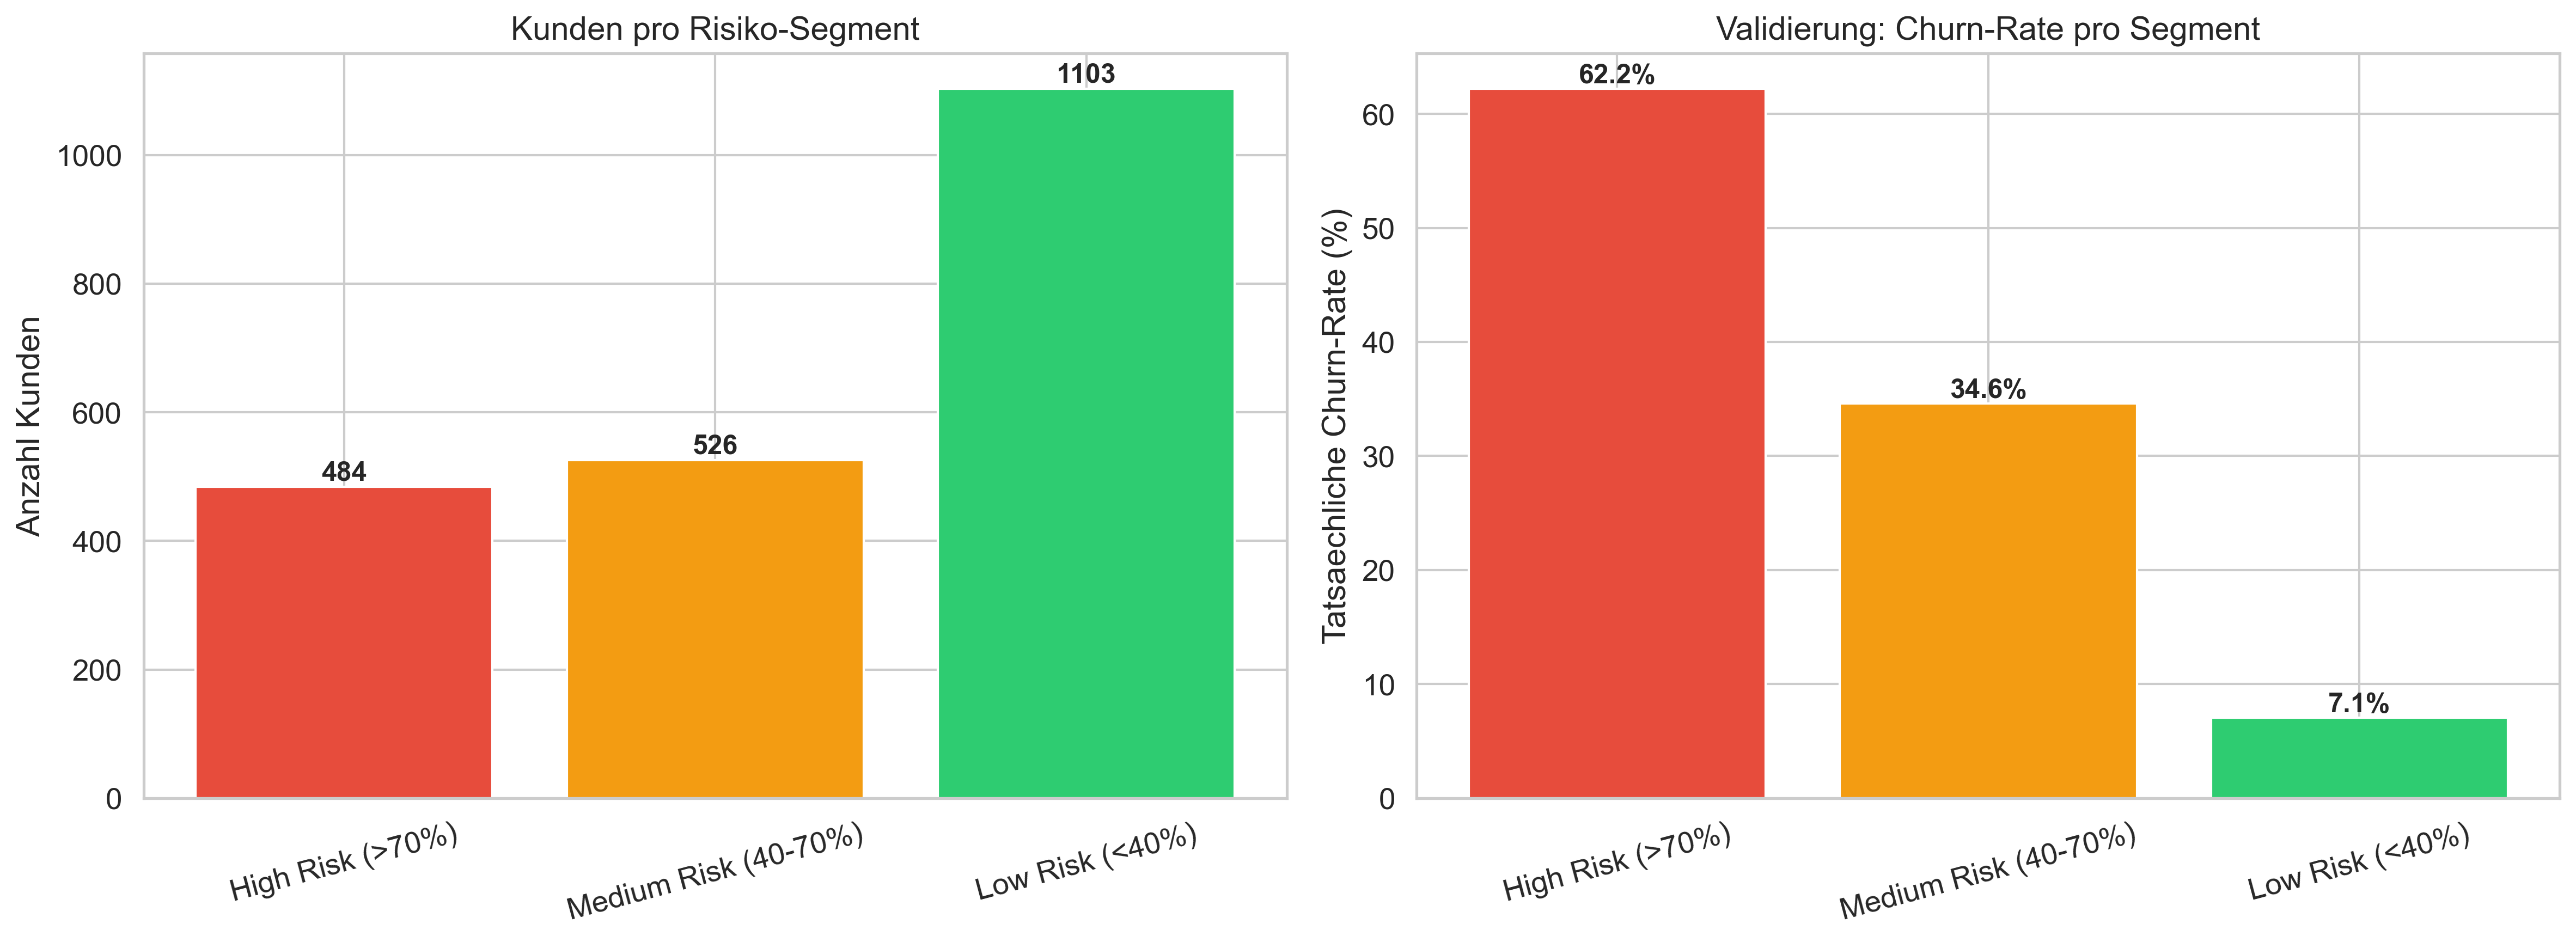

In [4]:
# Visualisierung: Verteilung der Segmente
colors_seg = {"High Risk (>70%)": "#e74c3c", "Medium Risk (40-70%)": "#f39c12", "Low Risk (<40%)": "#2ecc71"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Anzahl pro Segment
seg_order = ["High Risk (>70%)", "Medium Risk (40-70%)", "Low Risk (<40%)"]
seg_counts = segments["segment"].value_counts().reindex(seg_order)
bars = axes[0].bar(seg_counts.index, seg_counts.values, color=[colors_seg[s] for s in seg_counts.index])
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
        f"{val}", ha="center", fontsize=12, fontweight="bold",
    )
axes[0].set_ylabel("Anzahl Kunden")
axes[0].set_title("Kunden pro Risiko-Segment")
axes[0].tick_params(axis="x", rotation=15)

# Tatsaechliche Churn-Rate pro Segment
churn_rates = segments.groupby("segment")["actual_churn"].mean().reindex(seg_order) * 100
bars = axes[1].bar(churn_rates.index, churn_rates.values, color=[colors_seg[s] for s in churn_rates.index])
for bar, val in zip(bars, churn_rates.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold",
    )
axes[1].set_ylabel("Tatsaechliche Churn-Rate (%)")
axes[1].set_title("Validierung: Churn-Rate pro Segment")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig("plots/31_risiko_segmentierung.png")
plt.show()

---
## 11.2 Szenario-Simulation

In [5]:
# Annahmen
CLV = 2000  # Customer Lifetime Value in CHF
CAMPAIGN_COST = 50  # Kosten pro kontaktiertem Kunden in CHF

n_churner_test = int(y_test.sum())
n_total_test = len(y_test)

# Hochrechnung auf Gesamtdatensatz (7043 Kunden)
churn_rate = y_test.mean()
n_total = 7043
n_churner = int(n_total * churn_rate)

print(f"Gesamtkunden: {n_total:,}")
print(f"Erwartete Churner: {n_churner:,} ({churn_rate*100:.1f}%)")
print(f"CLV: {CLV:,} CHF")
print(f"Kampagnenkosten pro Kontakt: {CAMPAIGN_COST} CHF")

Gesamtkunden: 7,043
Erwartete Churner: 1,869 (26.5%)
CLV: 2,000 CHF
Kampagnenkosten pro Kontakt: 50 CHF


In [6]:
# Szenarien berechnen
scenarios = []

# Szenario 1: Ohne Modell
loss_no_model = n_churner * CLV
scenarios.append({
    "Szenario": "Ohne Modell",
    "Erkannt (%)": 0,
    "Gerettet (%)": 0,
    "Gerettete Kunden": 0,
    "Geretteter Umsatz (CHF)": 0,
    "Kampagnenkosten (CHF)": 0,
    "Verlust (CHF)": loss_no_model,
    "Netto-Ertrag vs. Nichtstun (CHF)": 0,
})

# Szenario 2: Konservativ (60% erkannt, 30% gerettet)
erkannt_kons = int(n_churner * 0.6)
gerettet_kons = int(erkannt_kons * 0.3)
umsatz_kons = gerettet_kons * CLV
kosten_kons = erkannt_kons * CAMPAIGN_COST
scenarios.append({
    "Szenario": "Konservativ",
    "Erkannt (%)": 60,
    "Gerettet (%)": 30,
    "Gerettete Kunden": gerettet_kons,
    "Geretteter Umsatz (CHF)": umsatz_kons,
    "Kampagnenkosten (CHF)": kosten_kons,
    "Verlust (CHF)": loss_no_model - umsatz_kons + kosten_kons,
    "Netto-Ertrag vs. Nichtstun (CHF)": umsatz_kons - kosten_kons,
})

# Szenario 3: Optimistisch (80% erkannt, 40% gerettet)
erkannt_opt = int(n_churner * 0.8)
gerettet_opt = int(erkannt_opt * 0.4)
umsatz_opt = gerettet_opt * CLV
kosten_opt = erkannt_opt * CAMPAIGN_COST
scenarios.append({
    "Szenario": "Optimistisch",
    "Erkannt (%)": 80,
    "Gerettet (%)": 40,
    "Gerettete Kunden": gerettet_opt,
    "Geretteter Umsatz (CHF)": umsatz_opt,
    "Kampagnenkosten (CHF)": kosten_opt,
    "Verlust (CHF)": loss_no_model - umsatz_opt + kosten_opt,
    "Netto-Ertrag vs. Nichtstun (CHF)": umsatz_opt - kosten_opt,
})

scenario_df = pd.DataFrame(scenarios)
scenario_df.style.format({
    "Geretteter Umsatz (CHF)": "{:,.0f}",
    "Kampagnenkosten (CHF)": "{:,.0f}",
    "Verlust (CHF)": "{:,.0f}",
    "Netto-Ertrag vs. Nichtstun (CHF)": "{:,.0f}",
})

,Szenario,Erkannt (%),Gerettet (%),Gerettete Kunden,Geretteter Umsatz (CHF),Kampagnenkosten (CHF),Verlust (CHF),Netto-Ertrag vs. Nichtstun (CHF)
0,Ohne Modell,0,0,0,0,0,"3,738,000",0
1,Konservativ,60,30,336,"672,000","56,050","3,122,050","615,950"
2,Optimistisch,80,40,598,"1,196,000","74,750","2,616,750","1,121,250"


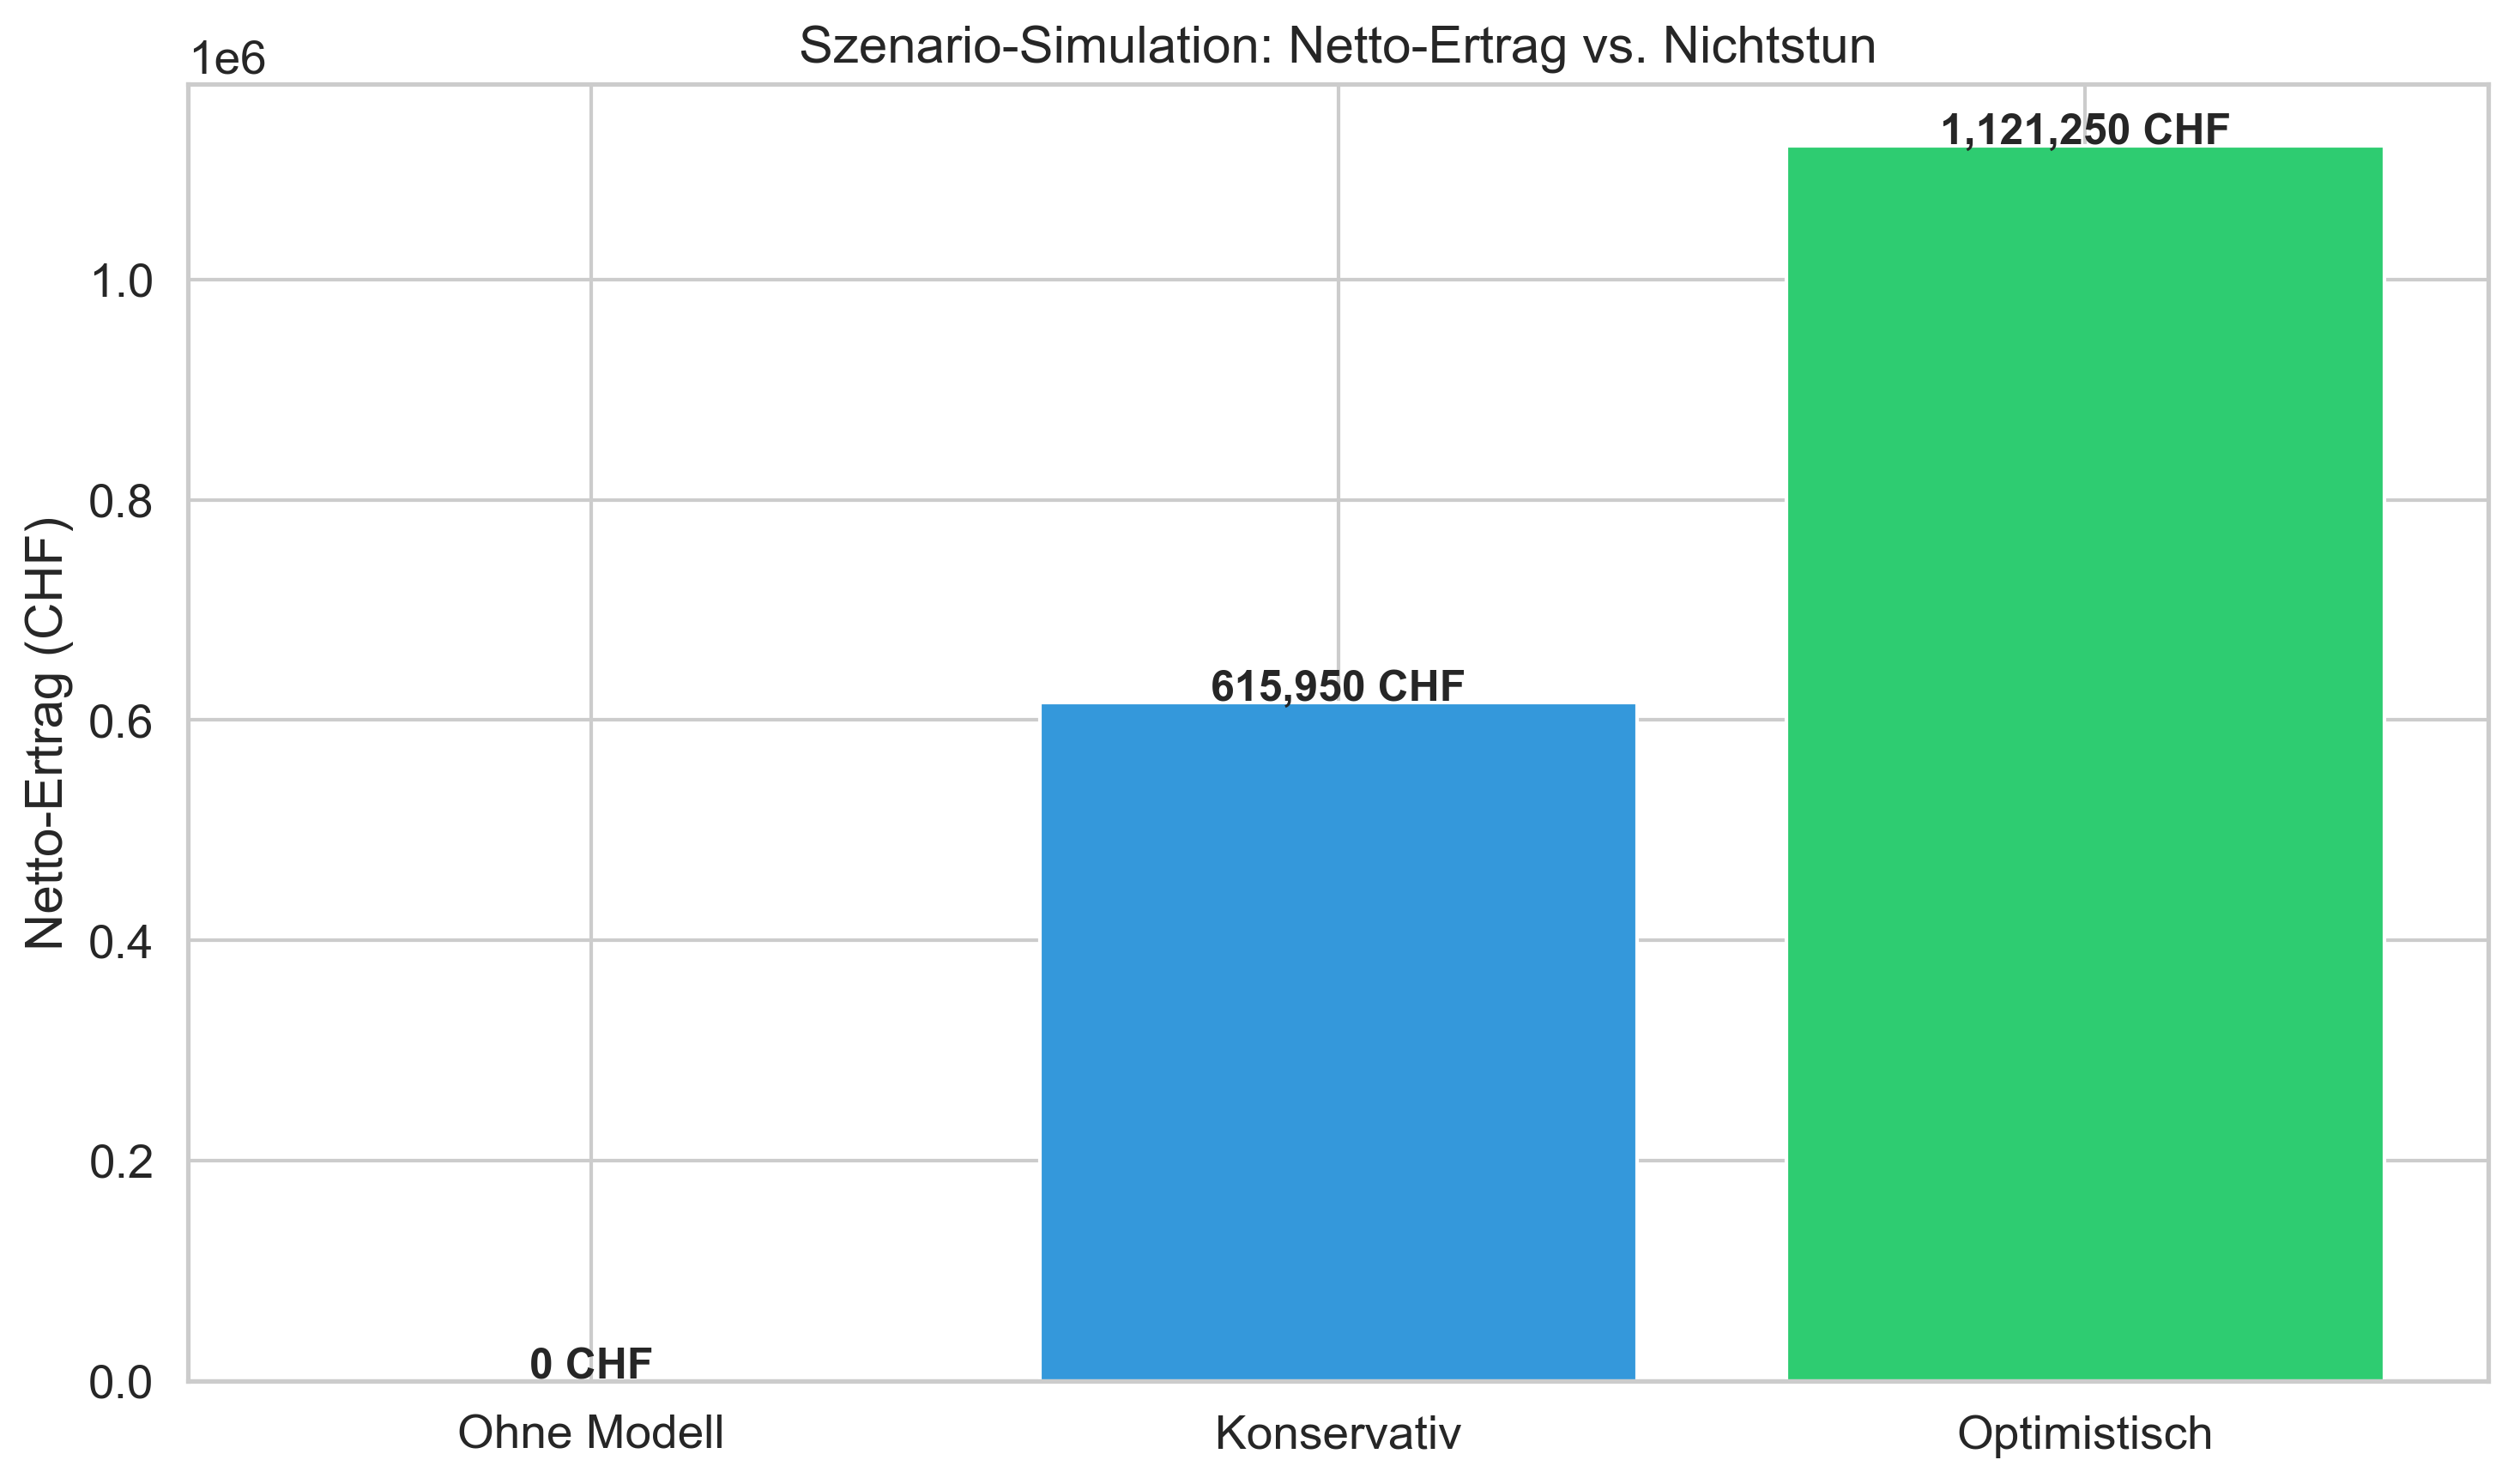

In [7]:
# Visualisierung: Netto-Ertrag pro Szenario
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#95a5a6", "#3498db", "#2ecc71"]
bars = ax.bar(
    scenario_df["Szenario"],
    scenario_df["Netto-Ertrag vs. Nichtstun (CHF)"],
    color=colors,
)
for bar, val in zip(bars, scenario_df["Netto-Ertrag vs. Nichtstun (CHF)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
        f"{val:,.0f} CHF", ha="center", fontsize=12, fontweight="bold",
    )
ax.set_ylabel("Netto-Ertrag (CHF)")
ax.set_title("Szenario-Simulation: Netto-Ertrag vs. Nichtstun")
plt.tight_layout()
fig.savefig("plots/32_szenario_simulation.png")
plt.show()

---
## 12. Inference-Test mit Demo-Personas

In [8]:
# Artefakte laden
preprocessor = joblib.load("models/preprocessor.pkl")
explainer = joblib.load("models/shap_explainer.pkl")

print("=== Frau Mueller (High-Risk-Profil) ===")
result_mueller = predict_churn(
    PERSONA_FRAU_MUELLER,
    model=xgb_model, preprocessor=preprocessor, explainer=explainer,
)
print(f"Churn-Score: {result_mueller['score']:.3f}")
print(f"Risiko:      {result_mueller['risk_label']}")

print("\n=== Herr Weber (Low-Risk-Profil) ===")
result_weber = predict_churn(
    PERSONA_HERR_WEBER,
    model=xgb_model, preprocessor=preprocessor, explainer=explainer,
)
print(f"Churn-Score: {result_weber['score']:.3f}")
print(f"Risiko:      {result_weber['risk_label']}")

=== Frau Mueller (High-Risk-Profil) ===
Churn-Score: 0.699
Risiko:      Medium Risk

=== Herr Weber (Low-Risk-Profil) ===
Churn-Score: 0.157
Risiko:      Low Risk


---
## Ergebnisse speichern

In [9]:
scenario_df.to_csv("data/processed/szenario_simulation.csv", index=False)
seg_summary.to_csv("data/processed/risiko_segmentierung.csv")

print("Alle Ergebnisse gespeichert:")
print("  - data/processed/szenario_simulation.csv")
print("  - data/processed/risiko_segmentierung.csv")
print("  - models/xgboost.pkl")
print("  - models/random_forest.pkl")
print("  - models/preprocessor.pkl")
print("  - models/shap_explainer.pkl")
print("\nProjekt abgeschlossen. Bereit fuer Dashboard.")

Alle Ergebnisse gespeichert:
  - data/processed/szenario_simulation.csv
  - data/processed/risiko_segmentierung.csv
  - models/xgboost.pkl
  - models/random_forest.pkl
  - models/preprocessor.pkl
  - models/shap_explainer.pkl

Projekt abgeschlossen. Bereit fuer Dashboard.
